In [1]:
import warnings
warnings.filterwarnings("ignore")

## Step 1: Import Required Libraries

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

## Step 2: Load Dataset

In [3]:
data = pd.read_csv("shopkart_sales_dataset.csv")

In [4]:
data.head()

,Order_ID,Order_Date,Customer_Age,Gender,City,Category,Qty,Unit Price,Discount,Shipping,Delivery,Sales,Profit,Rating,Profit_Category
0,SK100001,08-07-24,0.0,Male,Bengaluru,Beauty,5,37494,25,427.0,4,140602.50,11270.73,4.0,1
1,SK100002,21-03-25,150.0,Female,Lucknow,Beauty,4,45197,5,288.0,5,171748.60,13467.54,2.0,1
2,SK100003,29-09-24,26.0,Female,Jaipur,Grocery,-2,18665,20,298.0,3,44796.00,2194.68,4.0,0
3,SK100004,10-02-25,53.0,Male,Pune,Grocery,1,5483,120,175.0,9,5208.85,566.00,2.0,0
4,SK100005,10-03-24,33.0,Female,Delhi,Beauty,4,1562,-15,465.0,10,6248.00,880.50,4.0,0


In [5]:
data.tail()

,Order_ID,Order_Date,Customer_Age,Gender,City,Category,Qty,Unit Price,Discount,Shipping,Delivery,Sales,Profit,Rating,Profit_Category
4995,SK104996,15-06-25,40.0,Male,Mumbai,Furniture,4,21147,40,262.0,2,50752.8,3986.73,1.0,1
4996,SK104997,19-04-24,52.0,Female,Pune,Electronics,5,39828,30,166.0,4,139398.0,35836.96,5.0,1
4997,SK104998,13-09-24,56.0,Male,Jaipur,Electronics,1,11116,20,133.0,10,8892.8,437.40,5.0,0
4998,SK104999,18-09-24,21.0,Male,Chennai,Beauty,1,13259,40,205.0,3,7955.4,502.83,2.0,0
4999,SK105000,24-12-24,53.0,Female,Chennai,Furniture,1,28181,30,357.0,5,19726.7,4306.60,2.0,1


In [6]:
print("Number of Rows :", data.shape[0])
print("Number of Columns :", data.shape[1])

Number of Rows : 5000
Number of Columns : 15


## Step 3: Exploratory Data Analysis (EDA)

In [7]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   Order_ID         5000 non-null   object 
 1   Order_Date       5000 non-null   object 
 2   Customer_Age     4950 non-null   float64
 3   Gender           4967 non-null   object 
 4   City             5000 non-null   object 
 5   Category         4973 non-null   object 
 6   Qty              5000 non-null   int64  
 7   Unit Price       5000 non-null   int64  
 8   Discount         5000 non-null   int64  
 9   Shipping         4975 non-null   float64
 10  Delivery         5000 non-null   int64  
 11  Sales            5000 non-null   float64
 12  Profit           5000 non-null   float64
 13  Rating           4978 non-null   float64
 14  Profit_Category  5000 non-null   int64  
dtypes: float64(5), int64(5), object(5)
memory usage: 586.1+ KB


In [8]:
data.dtypes

Order_ID            object
Order_Date          object
Customer_Age       float64
Gender              object
City                object
Category            object
Qty                  int64
Unit Price           int64
Discount             int64
Shipping           float64
Delivery             int64
Sales              float64
Profit             float64
Rating             float64
Profit_Category      int64
dtype: object

In [9]:
data.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Age       50
Gender             33
City                0
Category           27
Qty                 0
Unit Price          0
Discount            0
Shipping           25
Delivery            0
Sales               0
Profit              0
Rating             22
Profit_Category     0
dtype: int64

#### Missing Values Percentage

In [10]:
missing = data.isnull().sum()

missing_percentage = (missing / len(data)) * 100

pd.DataFrame({
    "Missing Values": missing,
    "Percentage": missing_percentage.round(2)
})

,Missing Values,Percentage
Order_ID,0,0.00
Order_Date,0,0.00
Customer_Age,50,1.00
Gender,33,0.66
City,0,0.00
Category,27,0.54
Qty,0,0.00
Unit Price,0,0.00
Discount,0,0.00
Shipping,25,0.50


#### Duplicate Rows

In [11]:
print("Duplicate Rows :", data.duplicated().sum())

Duplicate Rows : 0


#### Statistical Summary

In [12]:
data.describe().T

,count,mean,std,min,25%,50%,75%,max
Customer_Age,4950.0,41.510505,13.994752,0.0,29.00,42.000,53.0000,150.0
Qty,5000.0,3.006800,1.417165,-2.0,2.00,3.000,4.0000,5.0
Unit Price,5000.0,25218.403400,14758.076146,219.0,12897.25,25115.500,37905.7500,250000.0
Discount,5000.0,18.437000,12.361739,-15.0,10.00,20.000,30.0000,120.0
Shipping,4975.0,322.230553,159.181210,50.0,187.00,316.000,461.0000,600.0
Delivery,5000.0,5.505000,2.878616,-3.0,3.00,5.000,8.0000,10.0
Sales,5000.0,62224.273950,50652.012504,210.4,22136.70,47465.400,91062.4500,249435.0
Profit,5000.0,10741.262846,10719.868245,-459.2,2874.31,7246.335,15389.0025,80000.0
Rating,4978.0,3.024106,1.411590,1.0,2.00,3.000,4.0000,5.0
Profit_Category,5000.0,0.741000,0.438129,0.0,0.00,1.000,1.0000,1.0


#### Statistical Summary (Categorical)

In [13]:
data.describe(include="object").T

,count,unique,top,freq
Order_ID,5000,5000,SK105000,1
Order_Date,5000,541,29-01-25,20
Gender,4967,2,Female,2495
City,5000,8,Bengaluru,646
Category,4973,6,Sports,854


#### Value Counts

In [14]:
data["Gender"].value_counts(dropna=False)

Gender
Female    2495
Male      2472
NaN         33
Name: count, dtype: int64

In [15]:
data["Category"].value_counts(dropna=False)

Category
Sports         854
Beauty         838
Fashion        833
Electronics    830
Grocery        817
Furniture      801
NaN             27
Name: count, dtype: int64

In [16]:
data["City"].value_counts()

City
Bengaluru    646
Hyderabad    644
Delhi        630
Mumbai       627
Pune         624
Chennai      623
Jaipur       608
Lucknow      598
Name: count, dtype: int64

In [17]:
data["Profit_Category"].value_counts()

Profit_Category
1    3705
0    1295
Name: count, dtype: int64

In [18]:
data["Profit_Category"].value_counts(normalize=True) * 100

Profit_Category
1    74.1
0    25.9
Name: proportion, dtype: float64

#### Correlation Matrix

In [19]:
numerical_data = data.select_dtypes(include=np.number)

correlation = numerical_data.corr()

correlation

,Customer_Age,Qty,Unit Price,Discount,Shipping,Delivery,Sales,Profit,Rating,Profit_Category
Customer_Age,1.000000,0.017304,-0.002883,-0.016831,-0.014025,-0.006787,0.013947,0.013267,0.006259,0.013099
Qty,0.017304,1.000000,0.016033,-0.006930,-0.008189,0.018723,0.586496,0.490321,-0.027195,0.340800
Unit Price,-0.002883,0.016033,1.000000,-0.031003,0.027123,0.004852,0.696962,0.584651,-0.010872,0.557179
Discount,-0.016831,-0.006930,-0.031003,1.000000,-0.021336,0.010352,-0.204355,-0.176046,-0.009527,-0.100983
Shipping,-0.014025,-0.008189,0.027123,-0.021336,1.000000,0.000567,0.019823,0.002849,0.000437,-0.028102
Delivery,-0.006787,0.018723,0.004852,0.010352,0.000567,1.000000,0.012380,0.016493,-0.007170,0.007451
Sales,0.013947,0.586496,0.696962,-0.204355,0.019823,0.012380,1.000000,0.841563,-0.020525,0.555670
Profit,0.013267,0.490321,0.584651,-0.176046,0.002849,0.016493,0.841563,1.000000,-0.024227,0.519156
Rating,0.006259,-0.027195,-0.010872,-0.009527,0.000437,-0.007170,-0.020525,-0.024227,1.000000,-0.022083
Profit_Category,0.013099,0.340800,0.557179,-0.100983,-0.028102,0.007451,0.555670,0.519156,-0.022083,1.000000


#### Heatmap

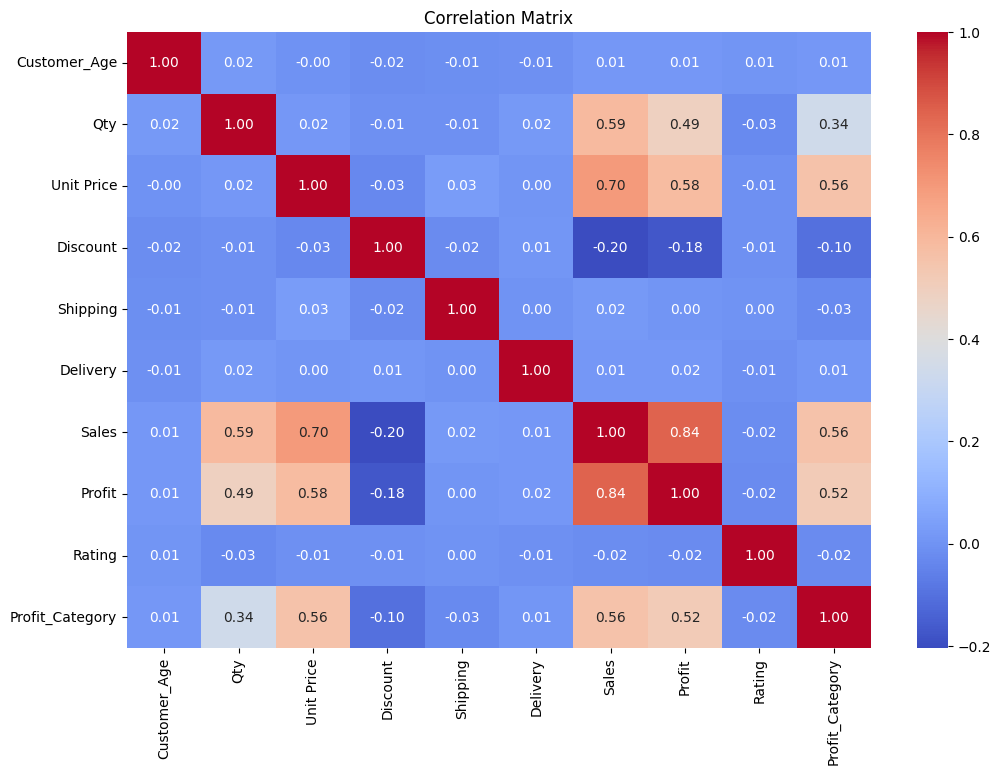

In [20]:
plt.figure(figsize=(12,8))

sns.heatmap(
    correlation,
    annot=True,
    cmap="coolwarm",
    fmt=".2f"
)
plt.title("Correlation Matrix")
plt.show()

#### Histogram

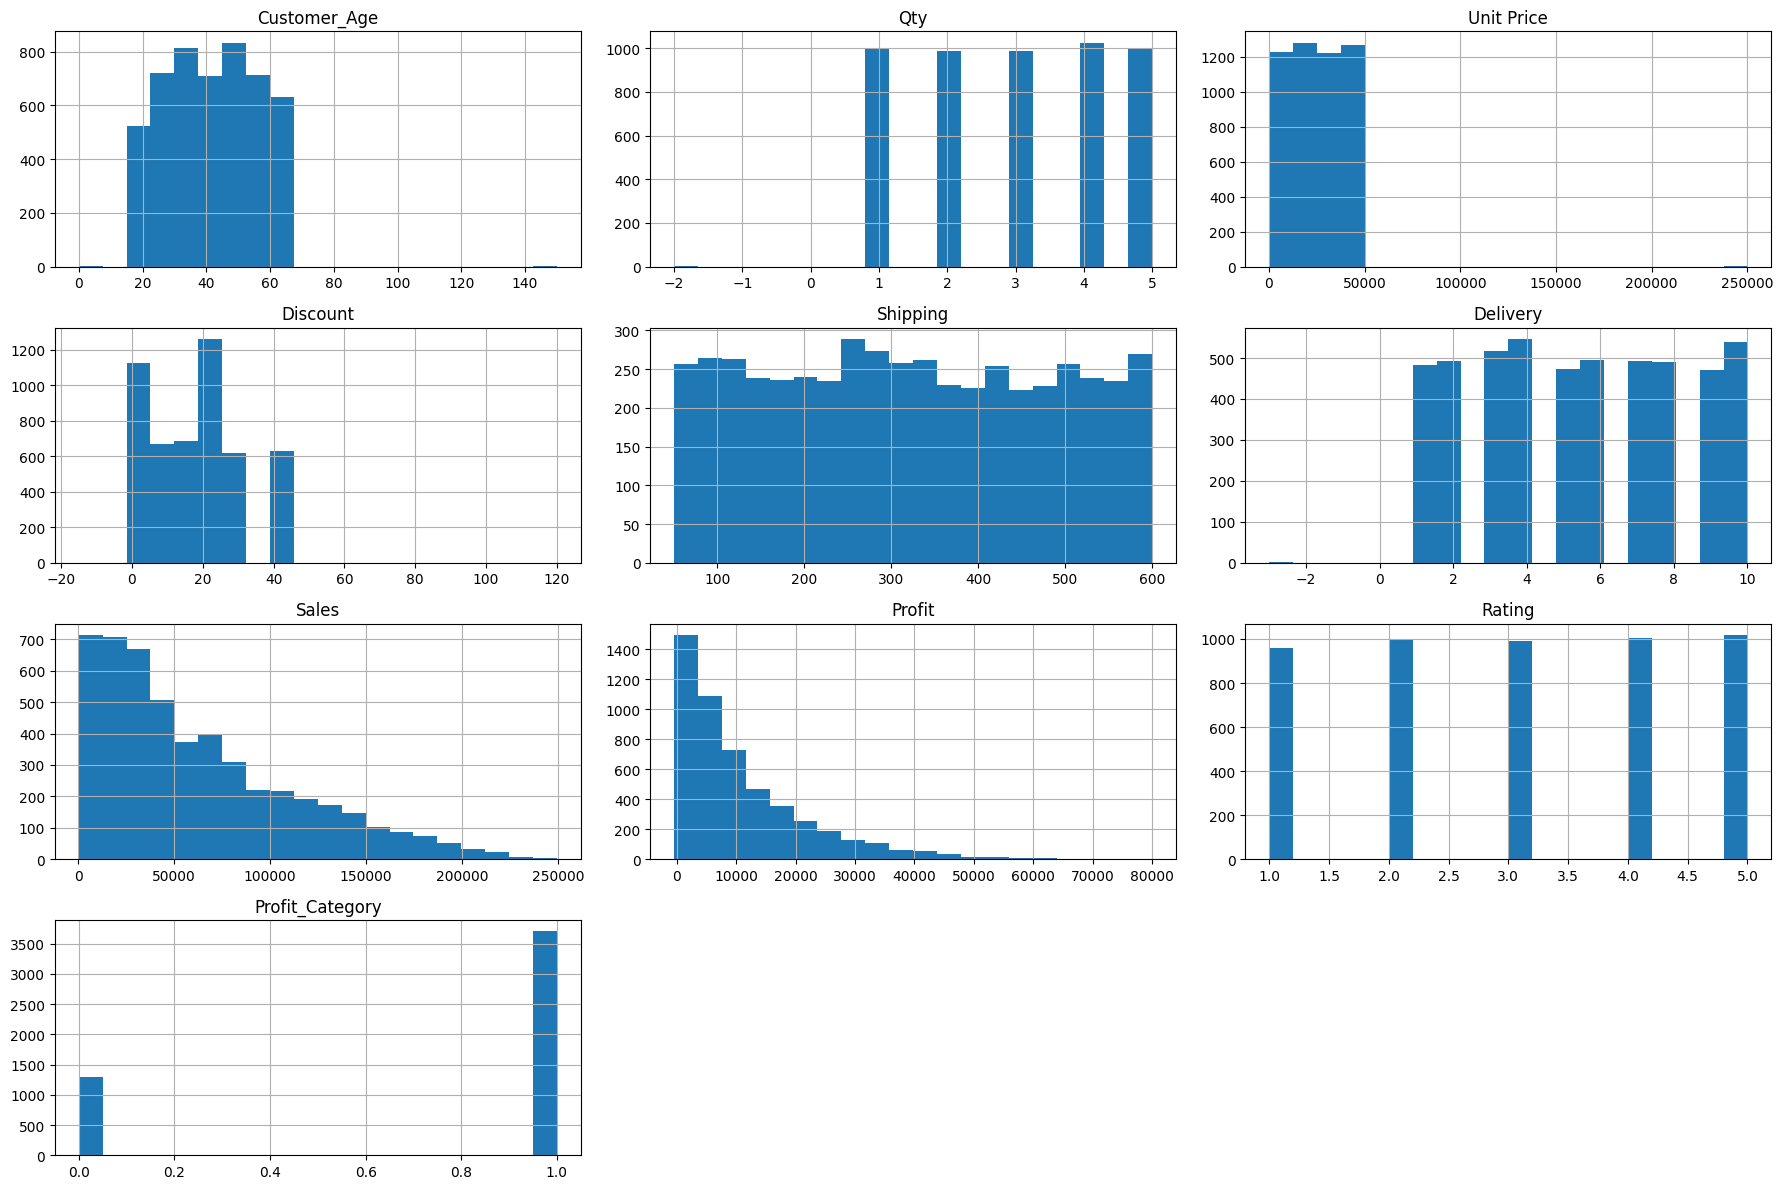

In [21]:
data.hist(figsize=(18,12), bins=20)

plt.tight_layout()

plt.show()

#### Categorical Columns

In [22]:
categorical_columns = ["Gender","City","Category","Profit_Category"]

for column in categorical_columns:
    print("=" * 50)
    print("Column :", column)
    print("Unique Values :", data[column].unique())
    print("Total Unique :", data[column].nunique())

Column : Gender
Unique Values : ['Male' 'Female' nan]
Total Unique : 2
Column : City
Unique Values : ['Bengaluru' 'Lucknow' 'Jaipur' 'Pune' 'Delhi' 'Chennai' 'Hyderabad'
 'Mumbai']
Total Unique : 8
Column : Category
Unique Values : ['Beauty' 'Grocery' 'Sports' 'Electronics' 'Furniture' 'Fashion' nan]
Total Unique : 6
Column : Profit_Category
Unique Values : [1 0]
Total Unique : 2


#### Count Plots

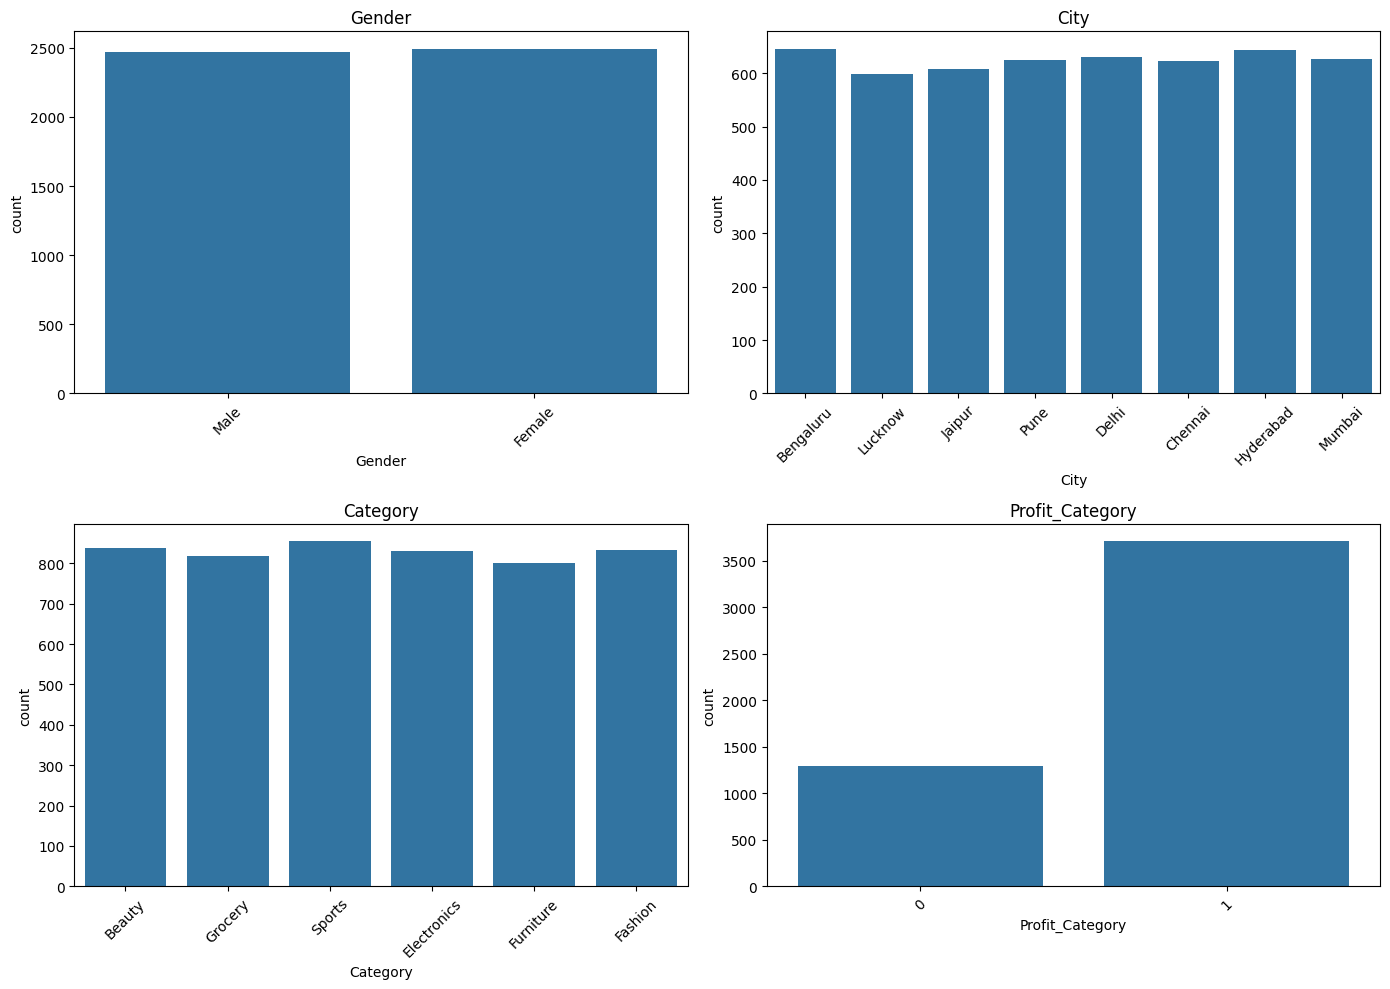

In [23]:
plt.figure(figsize=(14, 10))

for i, column in enumerate(categorical_columns, start=1):
    plt.subplot(2, 2, i)
    sns.countplot(data=data, x=column)
    plt.xticks(rotation=45)
    plt.title(column)
plt.tight_layout()
plt.show()

#### Numerical Columns

In [24]:
numerical_columns = data.select_dtypes(include=["int64", "float64"]).columns
print(numerical_columns)

Index(['Customer_Age', 'Qty', 'Unit Price', 'Discount', 'Shipping', 'Delivery',
       'Sales', 'Profit', 'Rating', 'Profit_Category'],
      dtype='object')


In [25]:
for column in numerical_columns:
    print("="*50)
    print(column)
    print("Minimum :", data[column].min())
    print("Maximum :", data[column].max())

Customer_Age
Minimum : 0.0
Maximum : 150.0
Qty
Minimum : -2
Maximum : 5
Unit Price
Minimum : 219
Maximum : 250000
Discount
Minimum : -15
Maximum : 120
Shipping
Minimum : 50.0
Maximum : 600.0
Delivery
Minimum : -3
Maximum : 10
Sales
Minimum : 210.4
Maximum : 249435.0
Profit
Minimum : -459.2
Maximum : 80000.0
Rating
Minimum : 1.0
Maximum : 5.0
Profit_Category
Minimum : 0
Maximum : 1


#### Boxplots

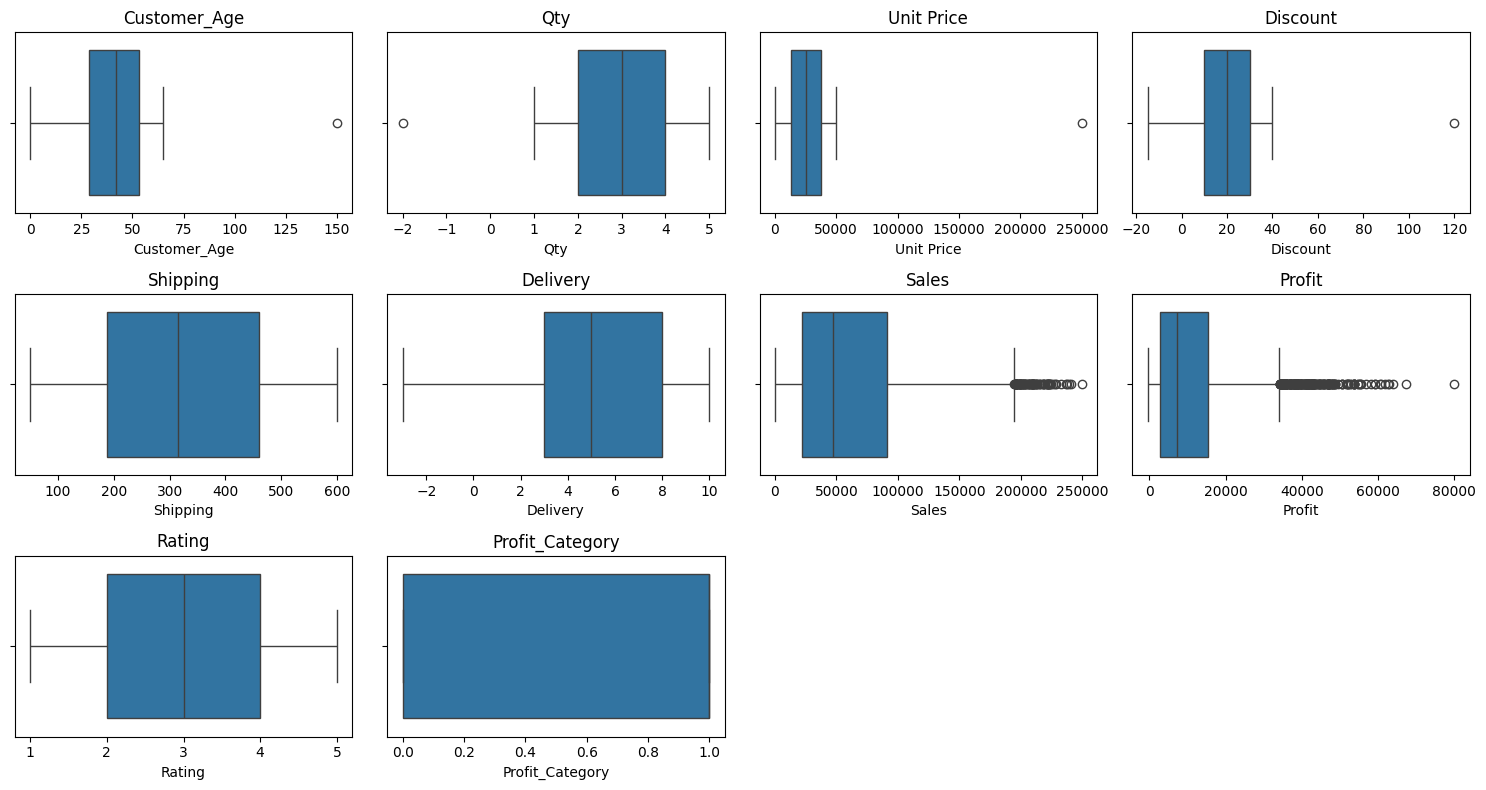

In [26]:
plt.figure(figsize=(15, 8))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=data[column])
    plt.title(column)
plt.tight_layout()
plt.show()

## Step 4: Data Cleaning

#### Check Duplicate Rows

In [27]:
duplicate_rows = data.duplicated().sum()
print("Duplicate Rows :", duplicate_rows)

Duplicate Rows : 0


#### Check Missing Values

In [28]:
data.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Age       50
Gender             33
City                0
Category           27
Qty                 0
Unit Price          0
Discount            0
Shipping           25
Delivery            0
Sales               0
Profit              0
Rating             22
Profit_Category     0
dtype: int64

### Convert Invalid Values into Missing Values (NaN)

In [29]:
data.columns

Index(['Order_ID', 'Order_Date', 'Customer_Age', 'Gender', 'City', 'Category',
       'Qty', 'Unit Price', 'Discount', 'Shipping', 'Delivery', 'Sales',
       'Profit', 'Rating', 'Profit_Category'],
      dtype='object')

#### Age

In [30]:
data.loc[(data["Customer_Age"] < 18) | (data["Customer_Age"] > 80), "Customer_Age"] = np.nan

#### Quantity

In [31]:
data.loc[data["Qty"] <= 0,"Qty"] = np.nan

#### Discount

In [32]:
data.loc[(data["Discount"] < 0) | (data["Discount"] > 100),"Discount"] = np.nan

#### Delivery

In [33]:
data.loc[data["Delivery"] <= 0,"Delivery"] = np.nan

### Verify Missing Values Again

In [34]:
data.isnull().sum()

Order_ID            0
Order_Date          0
Customer_Age       52
Gender             33
City                0
Category           27
Qty                 1
Unit Price          0
Discount            2
Shipping           25
Delivery            1
Sales               0
Profit              0
Rating             22
Profit_Category     0
dtype: int64

### Handle Missing Values

#### Numerical Columns

In [35]:
numerical_fill_columns = ["Customer_Age","Qty","Discount","Shipping","Delivery","Rating"]

for column in numerical_fill_columns:

    data[column] = data[column].fillna(data[column].median())

#### Categorical Columns

In [36]:
categorical_fill_columns = ["Gender","Category"]

for column in categorical_fill_columns:

    data[column] = data[column].fillna(data[column].mode()[0])

### Verify Missing Values

In [37]:
data.isnull().sum()

Order_ID           0
Order_Date         0
Customer_Age       0
Gender             0
City               0
Category           0
Qty                0
Unit Price         0
Discount           0
Shipping           0
Delivery           0
Sales              0
Profit             0
Rating             0
Profit_Category    0
dtype: int64

In [38]:
data.shape

(5000, 15)

### Convert Order_Date into Datetime

#### Check Current Data Type

In [39]:
data["Order_Date"].dtype

dtype('O')

#### Convert to Datetime

In [40]:
data["Order_Date"] = pd.to_datetime(data["Order_Date"])

#### Verify Conversion

In [41]:
data["Order_Date"].dtype

dtype('<M8[ns]')

### Validate Categorical Values

This ensures that no unexpected category values remain after cleaning.

In [42]:
for column in categorical_columns:
    print(f"\n{'='*40}")
    print(f"Unique Values in {column}")
    print(f"{'='*40}")
    print(data[column].unique())


Unique Values in Gender
['Male' 'Female']

Unique Values in City
['Bengaluru' 'Lucknow' 'Jaipur' 'Pune' 'Delhi' 'Chennai' 'Hyderabad'
 'Mumbai']

Unique Values in Category
['Beauty' 'Grocery' 'Sports' 'Electronics' 'Furniture' 'Fashion']

Unique Values in Profit_Category
[1 0]


### Verify Data Types

After cleaning, verify the data types one final time.

In [43]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype         
---  ------           --------------  -----         
 0   Order_ID         5000 non-null   object        
 1   Order_Date       5000 non-null   datetime64[ns]
 2   Customer_Age     5000 non-null   float64       
 3   Gender           5000 non-null   object        
 4   City             5000 non-null   object        
 5   Category         5000 non-null   object        
 6   Qty              5000 non-null   float64       
 7   Unit Price       5000 non-null   int64         
 8   Discount         5000 non-null   float64       
 9   Shipping         5000 non-null   float64       
 10  Delivery         5000 non-null   float64       
 11  Sales            5000 non-null   float64       
 12  Profit           5000 non-null   float64       
 13  Rating           5000 non-null   float64       
 14  Profit_Category  5000 non-null   int64  

## Step 5: Outlier Detection & Removal

### Boxplot

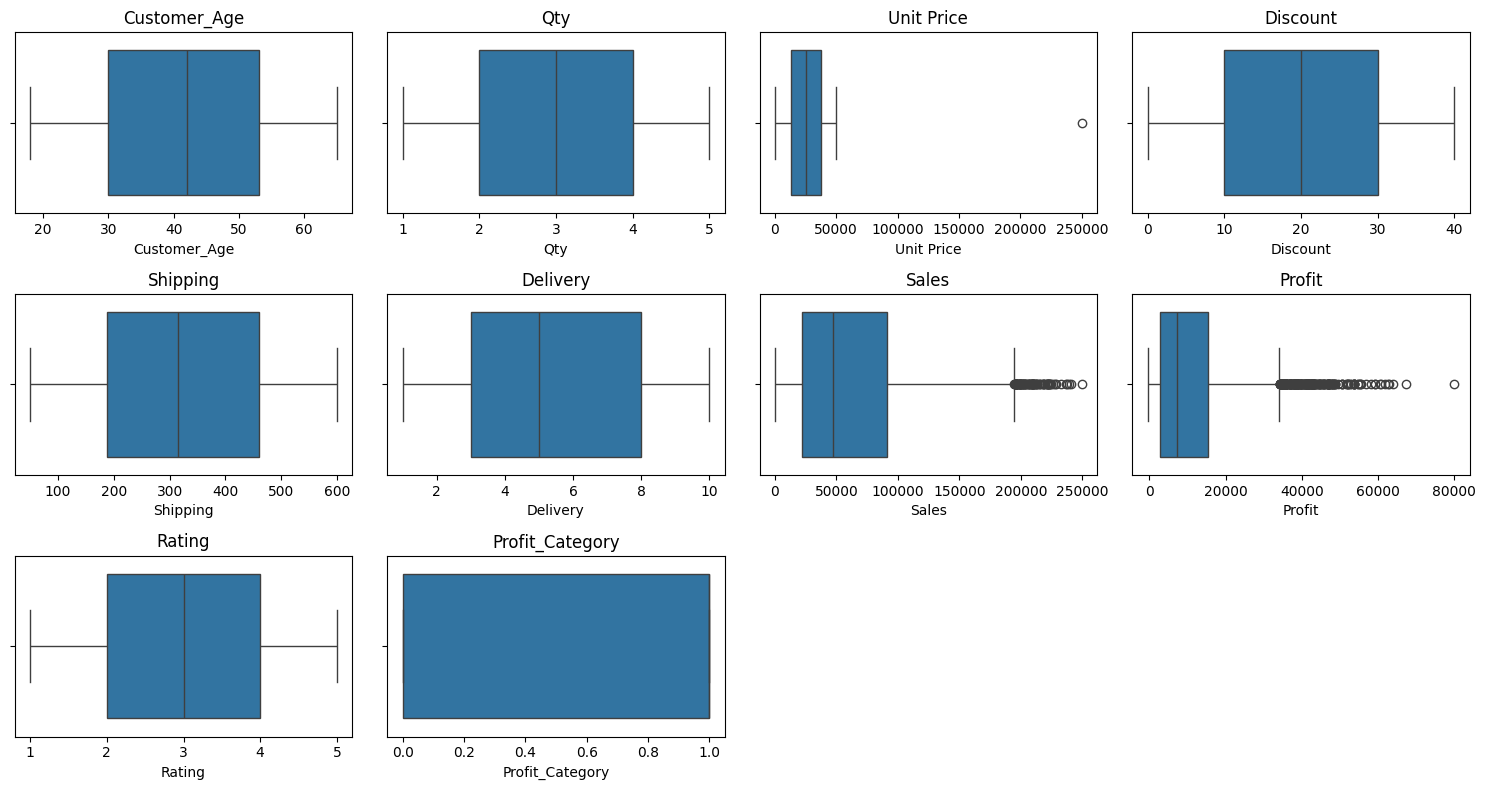

In [44]:
plt.figure(figsize=(15, 8))
for i, column in enumerate(numerical_columns, 1):
    plt.subplot(3, 4, i)
    sns.boxplot(x=data[column])
    plt.title(column)
plt.tight_layout()
plt.show()

In [45]:
data.shape

(5000, 15)

### Visualize Outliers

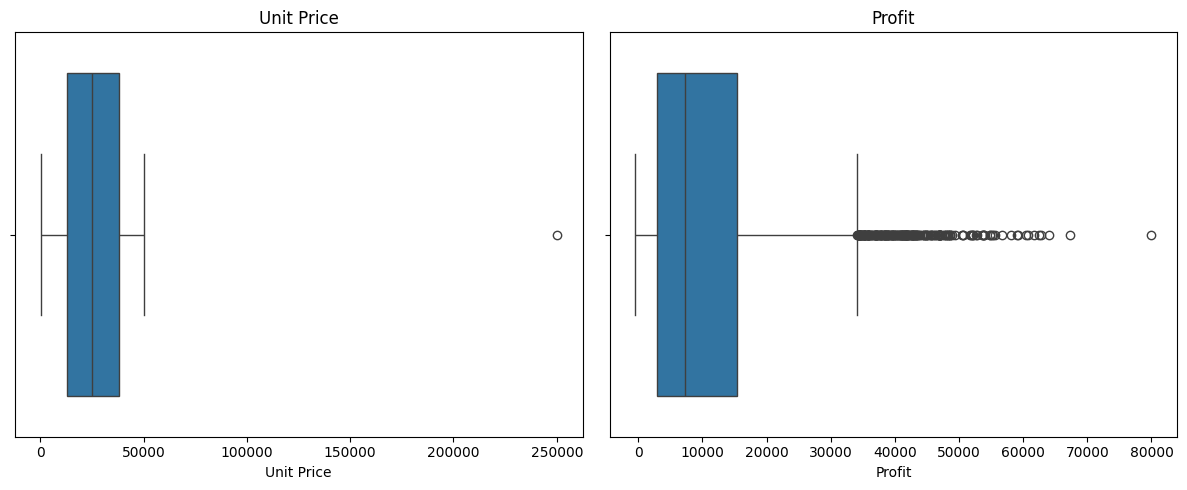

In [46]:
outlier_columns = ["Unit Price", "Profit"]
plt.figure(figsize=(12, 5))
for i, column in enumerate(outlier_columns, start=1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=data[column])
    plt.title(column)
plt.tight_layout()
plt.show()

### Function to Remove Outliers Using IQR

In [47]:
outlier_columns = ["Unit Price", "Profit"]
def remove_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_limit = Q1 - (1.5 * IQR)
    upper_limit = Q3 + (1.5 * IQR)
    df = df[(df[column] >= lower_limit) & (df[column] <= upper_limit)]
    return df

### Remove Outliers

In [48]:
for column in outlier_columns:
    data = remove_outliers_iqr(data, column)

In [49]:
data.shape

(4779, 15)

### Verify Outliers Using Boxplots

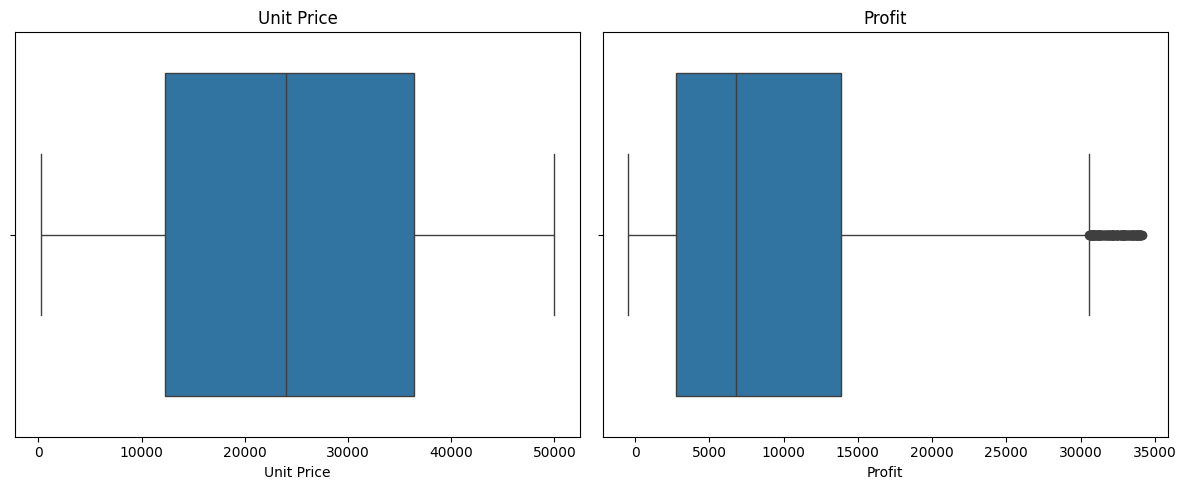

In [50]:
plt.figure(figsize=(12, 5))
for i, column in enumerate(outlier_columns, start=1):
    plt.subplot(1, 2, i)
    sns.boxplot(x=data[column])
    plt.title(column)
plt.tight_layout()
plt.show()

## Step 6: Feature Engineering

### Create Month

In [51]:
data["Month"] = data["Order_Date"].dt.month
data[["Order_Date", "Month"]].head()

,Order_Date,Month
0,2024-08-07,8
1,2025-03-21,3
2,2024-09-29,9
3,2025-10-02,10
4,2024-10-03,10


### Create Year

In [52]:
data["Year"] = data["Order_Date"].dt.year
data[["Order_Date", "Year"]].head()

,Order_Date,Year
0,2024-08-07,2024
1,2025-03-21,2025
2,2024-09-29,2024
3,2025-10-02,2025
4,2024-10-03,2024


### Create Day of Week

Monday = 0 | Sunday = 6

In [53]:
data["Day_of_Week"] = data["Order_Date"].dt.dayofweek
data[["Order_Date", "Day_of_Week"]].head()

,Order_Date,Day_of_Week
0,2024-08-07,2
1,2025-03-21,4
2,2024-09-29,6
3,2025-10-02,3
4,2024-10-03,3


### Create Weekend Column

Saturday and Sunday = 1 | Otherwise = 0

In [54]:
data["Weekend"] = data["Day_of_Week"].apply(lambda x: 1 if x >= 5 else 0)
data[["Day_of_Week", "Weekend"]].head()

,Day_of_Week,Weekend
0,2,0
1,4,0
2,6,1
3,3,0
4,3,0


### Create Profit Margin

In [55]:
data["Profit_Margin"] = (data["Profit"] / data["Sales"]) * 100
data[["Sales", "Profit", "Profit_Margin"]].head()

,Sales,Profit,Profit_Margin
0,140602.50,11270.73,8.016024
1,171748.60,13467.54,7.841426
2,44796.00,2194.68,4.899277
3,5208.85,566.00,10.866122
4,6248.00,880.50,14.092510


### Create Revenue per Item

In [56]:
data["Revenue_per_Item"] = data["Sales"] / data["Qty"]
data[["Sales", "Qty", "Revenue_per_Item"]].head()

,Sales,Qty,Revenue_per_Item
0,140602.50,5.0,28120.50
1,171748.60,4.0,42937.15
2,44796.00,3.0,14932.00
3,5208.85,1.0,5208.85
4,6248.00,4.0,1562.00


In [57]:
data.shape

(4779, 21)

## Step 7: Encoding

### Categorical Columns

In [58]:
for column in categorical_columns:

    print(f"\n{'='*40}")
    print(f"Unique Values in {column}")
    print(f"{'='*40}")
    print(data[column].unique())


Unique Values in Gender
['Male' 'Female']

Unique Values in City
['Bengaluru' 'Lucknow' 'Jaipur' 'Pune' 'Delhi' 'Chennai' 'Hyderabad'
 'Mumbai']

Unique Values in Category
['Beauty' 'Grocery' 'Sports' 'Furniture' 'Fashion' 'Electronics']

Unique Values in Profit_Category
[1 0]


### Label Encoding

In [59]:
from sklearn.preprocessing import LabelEncoder
label_encoder = LabelEncoder()
data["Gender"] = label_encoder.fit_transform(data["Gender"])
data[["Gender"]].head()

,Gender
0,1
1,0
2,0
3,1
4,0


### One-Hot Encoding

In [60]:
data = pd.get_dummies(data,columns=["City", "Category"],drop_first=True,dtype=int)

In [61]:
data.head()

,Order_ID,Order_Date,Customer_Age,Gender,Qty,Unit Price,Discount,Shipping,Delivery,Sales,...,City_Hyderabad,City_Jaipur,City_Lucknow,City_Mumbai,City_Pune,Category_Electronics,Category_Fashion,Category_Furniture,Category_Grocery,Category_Sports
0,SK100001,2024-08-07,42.0,1,5.0,37494,25.0,427.0,4.0,140602.50,...,0,0,0,0,0,0,0,0,0,0
1,SK100002,2025-03-21,42.0,0,4.0,45197,5.0,288.0,5.0,171748.60,...,0,0,1,0,0,0,0,0,0,0
2,SK100003,2024-09-29,26.0,0,3.0,18665,20.0,298.0,3.0,44796.00,...,0,1,0,0,0,0,0,0,1,0
3,SK100004,2025-10-02,53.0,1,1.0,5483,20.0,175.0,9.0,5208.85,...,0,0,0,0,1,0,0,0,1,0
4,SK100005,2024-10-03,33.0,0,4.0,1562,20.0,465.0,10.0,6248.00,...,0,0,0,0,0,0,0,0,0,0


In [62]:
data.shape

(4779, 31)

## Step 8: Train Test Split

### Create Features and Target

In [63]:
X=data.drop(columns=["Order_ID","Order_Date","Profit_Category"])
y=data["Profit_Category"]

In [64]:
print(X.shape)
print(y.shape)

(4779, 28)
(4779,)


In [65]:
from sklearn.model_selection import train_test_split


In [66]:
X_train, X_test, y_train,y_test =train_test_split(X,y,test_size=0.20,random_state=42, stratify=y)

In [67]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print (y_test.shape)

(3823, 28)
(956, 28)
(3823,)
(956,)


In [68]:
from sklearn.preprocessing import StandardScaler

In [69]:
scaler=StandardScaler()

In [70]:
# Fit on training data and transform
X_train_scaled = scaler.fit_transform(X_train)

# Only transform test data (do not fit again!)
X_test_scaled = scaler.transform(X_test)


In [71]:
X_train_scaled=pd.DataFrame(X_train_scaled, columns=X_train.columns, index=X_train.index)
X_test_scaled=pd.DataFrame(X_test_scaled, columns=X_test.columns, index=X_test.index)


In [72]:
X_train_scaled.head()

,Customer_Age,Gender,Qty,Unit Price,Discount,Shipping,Delivery,Sales,Profit,Rating,...,City_Hyderabad,City_Jaipur,City_Lucknow,City_Mumbai,City_Pune,Category_Electronics,Category_Fashion,Category_Furniture,Category_Grocery,Category_Sports
2176,0.106282,-0.982625,0.738884,-0.435494,0.499887,-1.484569,-1.548730,-0.066162,-0.492173,-0.721137,...,-0.382976,-0.375758,-0.369384,-0.367094,-0.377117,2.272912,-0.450508,-0.436572,-0.437845,-0.468463
3536,-0.110458,1.017682,1.450408,-1.513930,1.722839,-1.114036,1.223340,-1.065362,-0.852951,0.692299,...,-0.382976,-0.375758,-0.369384,-0.367094,-0.377117,-0.439964,-0.450508,-0.436572,-0.437845,2.134640
2289,-0.543937,1.017682,-0.684165,-0.350922,-0.723066,-0.065240,0.530323,-0.494155,-0.482257,0.692299,...,-0.382976,-0.375758,2.707208,-0.367094,-0.377117,-0.439964,-0.450508,-0.436572,2.283913,-0.468463
3095,-1.266403,1.017682,-0.684165,-1.098681,1.722839,-1.635294,-0.855713,-1.024459,-0.824020,1.399018,...,-0.382976,-0.375758,-0.369384,-0.367094,-0.377117,-0.439964,-0.450508,2.290575,-0.437845,-0.468463
4067,1.623459,1.017682,-1.395690,0.863041,0.092236,0.594183,0.183814,-0.616177,-0.864811,1.399018,...,-0.382976,-0.375758,-0.369384,-0.367094,-0.377117,-0.439964,-0.450508,-0.436572,-0.437845,2.134640


In [73]:
X_test_scaled.head()

,Customer_Age,Gender,Qty,Unit Price,Discount,Shipping,Delivery,Sales,Profit,Rating,...,City_Hyderabad,City_Jaipur,City_Lucknow,City_Mumbai,City_Pune,Category_Electronics,Category_Fashion,Category_Furniture,Category_Grocery,Category_Sports
3369,-0.182705,-0.982625,1.450408,0.220292,0.907538,-0.875388,-1.202221,0.840630,1.000948,-0.014419,...,-0.382976,-0.375758,-0.369384,-0.367094,-0.377117,-0.439964,-0.450508,-0.436572,2.283913,-0.468463
1292,-0.471691,-0.982625,-1.395690,0.758242,0.907538,0.820271,0.530323,-0.718522,-0.770708,-1.427856,...,-0.382976,-0.375758,-0.369384,-0.367094,-0.377117,2.272912,-0.450508,-0.436572,-0.437845,-0.468463
4646,0.178528,-0.982625,0.738884,-0.791120,0.499887,0.424617,1.569849,-0.395659,-0.352468,-0.721137,...,-0.382976,-0.375758,-0.369384,2.724097,-0.377117,-0.439964,-0.450508,-0.436572,-0.437845,-0.468463
4353,-1.338649,-0.982625,-1.395690,0.859728,-1.130717,-1.704377,0.183814,-0.497616,-0.037396,0.692299,...,-0.382976,-0.375758,-0.369384,2.724097,-0.377117,-0.439964,-0.450508,2.290575,-0.437845,-0.468463
1263,0.250775,1.017682,-0.684165,-0.531343,0.092236,-0.159443,0.876831,-0.667702,-0.609292,-1.427856,...,-0.382976,-0.375758,-0.369384,-0.367094,-0.377117,-0.439964,-0.450508,-0.436572,2.283913,-0.468463


In [74]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.ensemble import GradientBoostingClassifier

In [75]:
lr_model=LogisticRegression(random_state=42)
dt_model=DecisionTreeRegressor(random_state=42)
rf_model= RandomForestClassifier(random_state=42)
knn_model=KNeighborsClassifier()
svm_model=SVC(random_state=42)
gb_model= GradientBoostingClassifier(random_state=42)

In [76]:
models={
    "Logistic Regression":lr_model,
    "Decision Tree":dt_model,
    "Random Forest":rf_model,
    "KNN":knn_model,
    "SVM":svm_model,
    "Gradient Boosting":gb_model}

In [77]:
for name, model in models.items():
    model.fit(X_train_scaled, y_train)

In [78]:
train_predictions={}
for name, model in models.items():
    train_predictions[name]=model.predict(X_train_scaled)

In [79]:
train_predictions={}
for name, model in models.items():
    train_predictions[name]=model.predict(X_test_scaled)

In [80]:
print("Traning Predinctions")
for model in train_predictions:
    print(model, ":", train_predictions[model][:10])
    

Traning Predinctions
Logistic Regression : [1 0 1 1 1 1 1 0 1 1]
Decision Tree : [1. 0. 1. 1. 1. 1. 1. 0. 1. 1.]
Random Forest : [1 0 1 1 1 1 1 0 1 1]
KNN : [1 1 1 1 1 1 1 0 1 1]
SVM : [1 0 1 1 1 1 1 0 1 1]
Gradient Boosting : [1 0 1 1 1 1 1 0 1 1]


In [81]:
comparison_test = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": train_predictions["Logistic Regression"]
})

comparison_test.head(10)


,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


In [82]:
comparison_test = pd.DataFrame({
    "Actual": y_test.values,
    "Predicted": train_predictions["Logistic Regression"]
})

comparison_test.head(10)


,Actual,Predicted
0,1,1
1,0,0
2,1,1
3,1,1
4,1,1
5,1,1
6,1,1
7,0,0
8,1,1
9,1,1


In [83]:
from sklearn.metrics import accuracy_score

In [84]:
result = []
for name, model in models.items():
    y_pred = model.predict(X_test_scaled)
    accuracy = accuracy_score(y_test, y_pred)
    result.append([name, accuracy])


In [85]:
result_df=pd.DataFrame(result,columns=["Model","Accuracy"])

In [86]:
result_df

,Model,Accuracy
0,Logistic Regression,0.975941
1,Decision Tree,1.000000
2,Random Forest,1.000000
3,KNN,0.857741
4,SVM,0.960251
5,Gradient Boosting,1.000000


In [92]:
result_df.sort_values(by="Accuracy", ascending=False , inplace=True)
result_df.reset_index(drop=True, inplace=True)
result_df


,Model,Accuracy
0,Decision Tree,1.000000
1,Random Forest,1.000000
2,Gradient Boosting,1.000000
3,Logistic Regression,0.975941
4,SVM,0.960251
5,KNN,0.857741


In [93]:
print("Best Model :", result_df.iloc[0]["Model"])
print("Accuracy :", round(result_df.iloc[0]["Accuracy"], 4))

Best Model : Decision Tree
Accuracy : 1.0


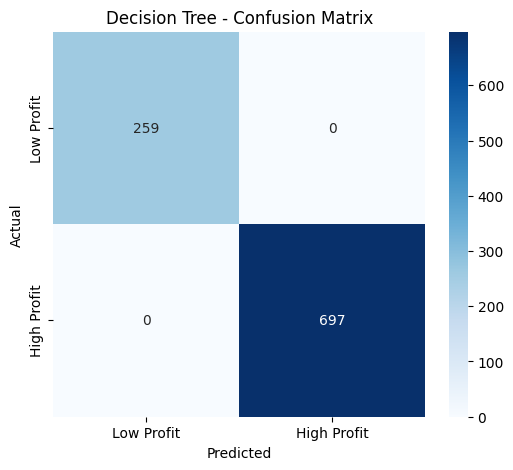

In [94]:
from sklearn.metrics import confusion_matrix

y_pred_dt = models["Decision Tree"].predict(X_test_scaled)

cm = confusion_matrix(y_test, y_pred_dt)

plt.figure(figsize=(6,5))
sns.heatmap(
    cm,
    annot=True,
    fmt="d",
    cmap="Blues",
    xticklabels=["Low Profit", "High Profit"],
    yticklabels=["Low Profit", "High Profit"]
)
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Decision Tree - Confusion Matrix")
plt.show()

In [97]:
decision_tree_model = models["Decision Tree"]
y_train_pred = decision_tree_model.predict(X_train_scaled)

In [98]:
from sklearn.metrics import accuracy_score

train_accuracy = accuracy_score(y_train, y_train_pred)
print("Training Accuracy :", train_accuracy)

Training Accuracy : 1.0


In [99]:
y_test_pred=dt_model.predict(X_test_scaled)

In [100]:
test_accuracy = accuracy_score(y_test, y_test_pred)
print("Training Accuracy :", test_accuracy)

Training Accuracy : 1.0


In [101]:
import joblib

In [102]:
joblib.dump(models["Decision Tree"],"decision_tree_model.pkl")

['decision_tree_model.pkl']

In [103]:
joblib.dump(scaler,"scaler.pkl")

['scaler.pkl']

In [104]:
loaded_model=joblib.load("decision_tree_model.pkl")

In [105]:
new_customer = pd.DataFrame([{
'Customer_Age':43,
'Gender':	0,
'Qty':	4,
'Unit Price':	18186,
'Discount':	25,
'Shipping':	86,
'Delivery':	1,
'Sales':	54558,
'Profit':	5239,
'Rating':	2,
'Month':	2,
'Year':	2024,
'Day_of_Week':	2,
'Weekend':	0,
'Profit_Margin':	9,
'Revenue_per_Item':	13639,
'City_Chennai':	0,
'City_Delhi':	0,
'City_Hyderabad':	0,
'City_Jaipur':	0,
'City_Lucknow':	0,
'City_Mumbai':	0,
'City_Pune':	0,
'Category_Electronics':	1,
'Category_Fashion':	0,
'Category_Furniture':	0,
'Category_Grocery':	0,
'Category_Sports':	0,
}])

In [107]:

new_customer_scaled = scaler.transform(new_customer)


new_prediction = loaded_model.predict(new_customer_scaled)

print("Predicted value:", new_prediction[0])


Predicted value: 1.0


In [109]:
if new_prediction[0]==1:
    print("High Profit")
else:
    print("Low Profit")

High Profit
